# VectorRAG for Alzheimer's Disease Literature -- Pipeline, Retrieval & Evaluation

This notebook is the **VectorRAG arm** of the comparison: chunk the literature, embed
every chunk with a dense retriever, store it in a vector database (ChromaDB), and
answer questions by pulling back the top-k most semantically similar chunks -- no
graph, no entities, no relations. Same corpus, same 30-question evaluation set, same
metric suite as the GraphRAG notebook, so the two retrieval paradigms can be compared
head-to-head.

## Why VectorRAG as the baseline?

VectorRAG is the standard, simplest form of retrieval-augmented generation: embed
chunks, embed the question, retrieve by cosine similarity. It's fast, requires no
graph construction or entity/relation extraction step, and is very strong on
single-fact lookup questions where the answer lives inside one contiguous passage.
Where it tends to struggle is exactly where GraphRAG is designed to help: questions
that require **connecting facts across multiple chunks or documents**.

## Pipeline overview -- 8 stages

| Stage | What happens |
|---|---|
| **1. Environment Setup** | Install dependencies, import libraries |
| **2. Data Loading & Chunking** | Load Alzheimer's abstracts, split into overlapping word chunks |
| **3. Embedding & Vector Store Construction** | Embed every chunk with BGE and store it in ChromaDB |
| **4. Vector Retrieval Pipeline** | Question -> embedding -> top-k similar chunks -> assembled context |
| **5. LLM Loading & VectorRAG Question Answering** | Load Qwen2.5-3B-Instruct, build the answer-generation function |
| **6. Quick Testing** | Sanity-check the pipeline on a handful of questions |
| **7. Formal Evaluation Setup** | Define answer-quality metrics (ROUGE-L, BERTScore) |
| **8. Retrieval/Answer-Quality Evaluation & Final Results** | Add Hit/Precision/Recall/MRR retrieval metrics, run the complete evaluation on all 30 questions, final scorecard |

# Stage 1: Environment Setup

## 1.1 Install Dependencies

Installs the VectorRAG-specific stack on top of the shared LLM/eval tooling:
`chromadb` (vector database), `sentence-transformers` (embedding model), `langchain` /
`langchain-community` (not directly used below but available for future extension),
plus `bert-score`, `rouge-score`, `evaluate`, and the usual data/plotting libraries.
The `scispacy spacy networkx neo` line at the end is leftover from the GraphRAG
notebook this was adapted from and isn't needed for the VectorRAG pipeline itself.


In [ ]:
!pip -q install chromadb
!pip -q install sentence-transformers
!pip -q install transformers
!pip -q install accelerate
!pip -q install bitsandbytes
!pip -q install langchain
!pip -q install langchain-community
!pip -q install bert-score
!pip -q install rouge-score
!pip -q install evaluate
!pip -q install pandas
!pip -q install tqdm
!pip -q install matplotlib
!pip -q install nltk
!pip -q install scikit-learn
!pip -q install scispacy spacy networkx neo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

## 1.2 Import Libraries

Pulls in ChromaDB, SentenceTransformers, the `transformers` generation stack, and the evaluation libraries (`rouge_score`, `bert_score`) used later.


In [ ]:
import os
import json
import glob
import time

import numpy as np
import pandas as pd

from tqdm import tqdm

import chromadb

from sentence_transformers import SentenceTransformer

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline
)

from rouge_score import rouge_scorer
from bert_score import score

import matplotlib.pyplot as plt

# Stage 2: Data Loading & Chunking

## 2.1 Define Paths

Paths to the same Alzheimer's article JSON folder and evaluation question set used by
the GraphRAG notebook, so both pipelines run over an identical corpus.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/ALZ/Dataset"

EVAL_PATH = "/content/drive/MyDrive/ALZ/eval_dataset.json"

## 2.2 Load Documents

Reads every JSON file in the dataset folder (skipping manifest files prefixed `_`), handling both single-document and list-of-documents JSON shapes.


In [ ]:
documents = []

json_files = sorted(glob.glob(os.path.join(DATASET_PATH, "*.json")))

for file in json_files:

    filename = os.path.basename(file)

    # Skip manifest files
    if filename.startswith("_"):
        continue

    with open(file, "r", encoding="utf-8") as f:

        data = json.load(f)

    # Handle single-document JSON
    if isinstance(data, dict):
        documents.append(data)

    # Handle list of documents
    elif isinstance(data, list):
        documents.extend(data)

print(f"\nLoaded {len(documents)} documents.")


Loaded 31 documents.


## 2.3 Inspect a Document

Sanity check on the shape of a loaded document (type + keys).


In [ ]:
print(type(documents[0]))
print()

print(documents[0].keys())

<class 'dict'>

dict_keys(['pmid', 'title', 'abstract', 'authors', 'journal', 'year', 'mesh_terms', 'doi', 'url', 'subtopic', 'source_type', 'article_id'])


## 2.4 Load Evaluation Questions

Loads the same 30-question held-out set used in the GraphRAG evaluation, for an apples-to-apples comparison.


In [ ]:
with open(EVAL_PATH, "r", encoding="utf-8") as f:

    eval_dataset = json.load(f)

questions = eval_dataset["questions"]

print(f"Loaded {len(questions)} evaluation questions.")

Loaded 30 evaluation questions.


## 2.5 Chunking Function

Splits text into overlapping word chunks -- 220 words per chunk with 40-word overlap (a different chunk size from the GraphRAG notebook's 300/50, tuned independently for this retrieval strategy).


In [ ]:
CHUNK_SIZE = 220
OVERLAP = 40


def create_chunks(text,
                  chunk_size=CHUNK_SIZE,
                  overlap=OVERLAP):

    words = text.split()

    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = " ".join(words[start:end])

        chunks.append(chunk)

        start += (chunk_size - overlap)

    return chunks

## 2.6 Create Chunks

Applies the chunking function to every article's title + abstract, keeping rich metadata (article ID, PMID, journal, year, authors, MeSH terms, subtopic, DOI, URL) attached to each chunk for later retrieval and citation.


In [ ]:

chunked_docs = []

chunk_id = 0

for article in documents:

    title = article.get("title", "")

    abstract = article.get("abstract", "")

    full_text = f"{title}\n\n{abstract}"

    chunks = create_chunks(full_text)

    for chunk in chunks:

        chunked_docs.append({

            "chunk_id": chunk_id,

            "article_id": article.get("article_id", ""),

            "pmid": article.get("pmid", ""),

            "title": title,

            "journal": article.get("journal", ""),

            "year": article.get("year", ""),

            "authors": article.get("authors", []),

            "mesh_terms": article.get("mesh_terms", []),

            "subtopic": article.get("subtopic", ""),

            "doi": article.get("doi", ""),

            "url": article.get("url", ""),

            "text": chunk

        })

        chunk_id += 1

print(f"Created {len(chunked_docs)} chunks.")

Created 43 chunks.


## 2.7 Inspect a Chunk

Prints one chunk record to confirm the structure looks right before embedding.


In [ ]:
chunked_docs[0]

{'chunk_id': 0,
 'article_id': 'pubmed_12672860',
 'pmid': '12672860',
 'title': "Memantine in moderate-to-severe Alzheimer's disease.",
 'journal': 'The New England journal of medicine',
 'year': '2003',
 'authors': ['Barry Reisberg',
  'Rachelle Doody',
  'Albrecht Stöffler',
  'Frederick Schmitt',
  'Steven Ferris',
  'Hans Jörg Möbius'],
 'mesh_terms': ['Activities of Daily Living',
  'Aged',
  'Alzheimer Disease',
  'Behavior',
  'Cognition',
  'Disease Progression',
  'Excitatory Amino Acid Antagonists',
  'Female',
  'Humans',
  'Male',
  'Memantine',
  'Middle Aged',
  'N-Methylaspartate',
  'Severity of Illness Index'],
 'subtopic': 'treatment_memantine',
 'doi': '10.1056/NEJMoa013128',
 'url': 'https://pubmed.ncbi.nlm.nih.gov/12672860/',
 'text': "Memantine in moderate-to-severe Alzheimer's disease. BACKGROUND: Overstimulation of the N-methyl-D-aspartate (NMDA) receptor by glutamate is implicated in neurodegenerative disorders. Accordingly, we investigated memantine, an NMDA 

## 2.8 Save Processed Chunks

Persists the full chunk list to Google Drive as `processed_chunks.json`.


In [ ]:
OUTPUT_PATH = "/content/drive/MyDrive/ALZ/processed_chunks.json"

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(chunked_docs, f, indent=4)

print(f"Saved {len(chunked_docs)} chunks.")
print(f"Output File: {OUTPUT_PATH}")

Saved 43 chunks.
Output File: /content/drive/MyDrive/ALZ/processed_chunks.json


# Stage 3: Embedding & Vector Store Construction

## 3.1 Load Embedding Model

Loads **BAAI/bge-base-en-v1.5** ("BGE"), a general-purpose dense embedding model, onto
GPU. This is a different embedding model from the GraphRAG notebook's SapBERT --
SapBERT is biomedical-entity-specialized, while BGE is a strong general-purpose
retrieval embedder tuned for passage-level semantic search, which fits VectorRAG's
chunk-level retrieval better than an entity-level embedder would.


In [ ]:
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    device="cuda"
)

print("Embedding Model Loaded Successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Loaded Successfully!


## 3.2 Test Embedding

Encodes one sample sentence to confirm the model loaded correctly and check the embedding dimensionality.


In [ ]:
sample_embedding = embedding_model.encode(
    "Alzheimer disease is associated with amyloid beta accumulation.",
    normalize_embeddings=True
)

print("Embedding Dimension:", len(sample_embedding))

Embedding Dimension: 768


## 3.3 Create ChromaDB Client

Opens a persistent ChromaDB client backed by local disk storage, so the vector index survives across sessions.


In [ ]:
import chromadb

client = chromadb.PersistentClient(
    path="/content/chromadb"
)

print("ChromaDB Client Created!")

ChromaDB Client Created!


## 3.4 Create or Load Collection

Gets (or creates, if it doesn't exist yet) the `alzheimers_vectordb` collection that will hold every chunk's embedding, text, and metadata.


In [ ]:
collection = client.get_or_create_collection(
    name="alzheimers_vectordb",
    metadata={
        "description": "Alzheimer Disease Vector Database"
    }
)

print("Collection Ready!")

Collection Ready!


## 3.5 Generate Embeddings for All Chunks

Batch-encodes every chunk's text with BGE (batch size 32, normalized embeddings) -- the core indexing step that turns the whole chunked corpus into vectors.


In [ ]:

texts = [
    doc["text"]
    for doc in chunked_docs
]

embeddings = embedding_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embeddings Shape:", embeddings.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings Shape: (43, 768)


## 3.6 Store Chunks in ChromaDB

Writes every chunk's embedding, raw text, and metadata (article ID, title, journal, year, subtopic) into the ChromaDB collection, one `add()` call per chunk.


In [ ]:
for i, doc in enumerate(chunked_docs):

    metadata = {
        "article_id": str(doc["article_id"]),
        "title": str(doc["title"]),
        "journal": str(doc["journal"]),
        "year": str(doc["year"]),
        "subtopic": str(doc["subtopic"])
    }

    collection.add(

        ids=[str(doc["chunk_id"])],

        embeddings=[embeddings[i].tolist()],

        documents=[doc["text"]],

        metadatas=[metadata]

    )

print("All Chunks Stored Successfully!")

All Chunks Stored Successfully!


## 3.7 Verify Collection Size

Confirms the number of vectors actually stored in the collection matches the number of chunks produced.


In [ ]:
collection.count()

43

# Stage 4: Vector Retrieval Pipeline


## 4.1 Vector Search Function (final)

Embeds the question (prefixed with BGE's recommended `"Represent this sentence for searching relevant passages: "` instruction, which measurably improves BGE's retrieval quality) and queries ChromaDB for the top-k most similar chunks.


In [ ]:
def retrieve_context(question, top_k=5):


    query = f"Represent this sentence for searching relevant passages: {question}"

    query_embedding = embedding_model.encode(
        query,
        normalize_embeddings=True
    )

    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k
    )

    return results

## 4.2 Test Retrieval

Runs a sample question through `retrieve_context()` to fetch the top-5 matching chunks.


In [ ]:
question = "What genes are associated with Alzheimer's disease?"

results = retrieve_context(question)

## 4.3 Inspect Retrieved Results

Prints each retrieved chunk's rank, title, subtopic, and a text preview -- a manual check on whether retrieval is actually pulling relevant passages.


In [ ]:
for i in range(len(results["documents"][0])):

    print("=" * 80)

    print(f"Rank {i+1}")

    print()

    print("Title:")
    print(results["metadatas"][0][i]["title"])

    print()

    print("Subtopic:")
    print(results["metadatas"][0][i]["subtopic"])

    print()

    print("Context:\n")

    print(results["documents"][0][i][:700])

    print()

Rank 1

Title:
Genetics of familial and sporadic Alzheimer's disease.

Subtopic:
genetics_familial

Context:

Genetics of familial and sporadic Alzheimer's disease. Alzheimer's disease (AD) is an age-related progressive neurodegenerative disorder. A majority of cases manifest as a late onset sporadic form but genetically the disease is divided into familial cases and sporadic cases. The familial form is due to mutations in three major genes (amyloid precursor protein (APP) gene, presenilin1 (PSEN1) gene and presenilin 2 (PSEN2) gene). In contrast, many genetic and environmental factors may contribute to determining the sporadic AD form. Despite many years of research and great progress in the knowledge of the molecular pathogenesis of AD, a full understanding of the etiology of the sporadic form is 

Rank 2

Title:
Alzheimer Disease

Subtopic:


Context:

Alzheimer Disease

Rank 3

Title:
Alzheimer's disease

Subtopic:


Context:

Alzheimer's disease

Rank 4

Title:
Alzheimer disease.


## 4.4 Build Context From Results

Flattens the retrieved chunk texts into a single context string, ready to be dropped into the generation prompt.


In [ ]:
def build_context(results):

    contexts = results["documents"][0]

    return "\n\n".join(contexts)

## 4.5 Preview Assembled Context

Prints the first 2000 characters of the assembled context for a sanity check.


In [ ]:
context = build_context(results)

print(context[:2000])

Genetics of familial and sporadic Alzheimer's disease. Alzheimer's disease (AD) is an age-related progressive neurodegenerative disorder. A majority of cases manifest as a late onset sporadic form but genetically the disease is divided into familial cases and sporadic cases. The familial form is due to mutations in three major genes (amyloid precursor protein (APP) gene, presenilin1 (PSEN1) gene and presenilin 2 (PSEN2) gene). In contrast, many genetic and environmental factors may contribute to determining the sporadic AD form. Despite many years of research and great progress in the knowledge of the molecular pathogenesis of AD, a full understanding of the etiology of the sporadic form is still not yet in reach. Genome-wide association studies (GWASs) revealed the genetic complexity of the disease and recent studies suggested that epigenetic mechanisms may play an essential role in disease development. This review provides an overview of all the milestones in AD genetic research, as 

# Stage 5: LLM Loading & VectorRAG Question Answering

## 5.1 Load Qwen Model

Loads **Qwen2.5-3B-Instruct** -- the same generation model used in the GraphRAG
notebook, so any answer-quality differences between the two notebooks come from the
retrieval strategy, not the generator. Loaded in fp16 on GPU (fp32 on CPU as a
fallback) with `trust_remote_code=True`.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    trust_remote_code=True
)

if device == "cpu":
    model = model.to("cpu")

print("Qwen Loaded Successfully!")

Using device: cuda


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen Loaded Successfully!


## 5.2 Text Generation Pipeline

Wraps the loaded model and tokenizer in a `transformers` text-generation pipeline.


In [ ]:

generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer
)

## 5.3 Prompt Template

Instructs the model to answer strictly from the retrieved context, stay concise (2-4 sentences), and explicitly say so if the context doesn't contain the answer -- the same grounding discipline as the GraphRAG prompt, adapted for chunk-based context instead of graph context.


In [ ]:
PROMPT_TEMPLATE = """
You are an expert medical assistant.

Answer ONLY using the information in the context.

Do not use outside knowledge.

Keep the answer concise (2–4 sentences).

If the context does not contain the answer, reply:

"I don't have enough information in the retrieved documents."

Context:
{context}

Question:
{question}

Answer:
"""

## 5.4 Build Prompt Function

Fills the prompt template with a given question and its retrieved context.


In [ ]:

def build_prompt(question, context):

    return PROMPT_TEMPLATE.format(
        question=question,
        context=context
    )

## 5.5 Generate Answer Function

Runs generation with `do_sample=False` (greedy decoding) and a low `temperature=0.2`, returning only the newly generated text via `return_full_text=False`.


In [ ]:

def generate_answer(prompt):

    outputs = generator(
        prompt,
        max_new_tokens=250,
        temperature=0.2,
        do_sample=False,
        return_full_text=False
    )

    return outputs[0]["generated_text"].strip()

## 5.6 End-to-End VectorRAG Function

Ties retrieval + prompting + generation together into a single `ask_vector_rag()` call that returns the answer alongside its context and raw ChromaDB results.


In [ ]:

def ask_vector_rag(
    question,
    top_k=5
):

    results = retrieve_context(
        question,
        top_k=top_k
    )

    context = build_context(results)

    prompt = build_prompt(
        question,
        context
    )

    answer = generate_answer(prompt)

    return {

        "question": question,

        "answer": answer,

        "context": context,

        "results": results

    }

# Stage 6: Quick Testing

## 6.1 Ask a Single Question

Runs the full VectorRAG pipeline end-to-end on one sample question.


In [ ]:
question = "What genes are associated with Alzheimer's disease?"

response = ask_vector_rag(question)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress th

## 6.2 Print the Answer


In [ ]:
print(response["answer"])

The genes associated with Alzheimer's disease include the amyloid precursor protein (APP) gene, presenilin1 (PSEN1) gene, and presenilin 2 (PSEN2) gene, which are involved in the familial form of Alzheimer's disease. For the sporadic form, many genetic and environmental factors contribute, but specific genes are not as clearly identified. I don't have enough information in the retrieved documents. To provide a more comprehensive answer, we would need additional details on genetic factors contributing to sporadic Alzheimer's disease.


## 6.3 Inspect Retrieved Sources

Prints the title and subtopic of every chunk that fed into the answer, for a transparency check on what evidence the model actually saw.


In [ ]:
for i, meta in enumerate(response["results"]["metadatas"][0]):

    print("=" * 80)

    print(f"Rank {i+1}")

    print("Title :", meta["title"])

    print("Subtopic :", meta["subtopic"])

    print()

Rank 1
Title : Genetics of familial and sporadic Alzheimer's disease.
Subtopic : genetics_familial

Rank 2
Title : Alzheimer Disease
Subtopic : 

Rank 3
Title : Alzheimer's disease
Subtopic : 

Rank 4
Title : Alzheimer disease.
Subtopic : synaptic_dysfunction

Rank 5
Title : APOE and Alzheimer's disease: advances in genetics, pathophysiology, and therapeutic approaches.
Subtopic : genetics_apoe



## 6.4 Run a Batch of Test Questions

Loops the pipeline over five varied sample questions (causes, diagnosis, biomarkers, drugs, APOE) as a broader smoke test before the formal evaluation.


In [ ]:
test_questions = [

    "What causes Alzheimer's disease?",

    "How is Alzheimer's diagnosed?",

    "What biomarkers are used?",

    "What drugs treat Alzheimer's?",

    "Explain APOE."
]

for q in test_questions:

    print("=" * 100)

    print("QUESTION:")

    print(q)

    print()

    response = ask_vector_rag(q)

    print("ANSWER:")

    print(response["answer"])

    print("\n")

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:
What causes Alzheimer's disease?



[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ANSWER:
Alzheimer's disease is caused by the presence of β-amyloid-containing plaques and tau-containing neurofibrillary tangles, which leads to synaptic homeostasis loss and dysfunction in endosomal/lysosomal clearance pathways. These changes result in reduced synaptic strength, synaptic loss, and neurodegeneration. Additionally, metabolic, vascular, and inflammatory changes, as well as comorbid pathologies, are key components of the disease process. I don't have enough information in the retrieved documents. To provide a comprehensive answer, more detailed information on the genetic and environmental factors contributing to Alzheimer's disease would be required.


QUESTION:
How is Alzheimer's diagnosed?



[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ANSWER:
Alzheimer's disease diagnosis is based on clinical presentation meeting certain criteria, along with fluid and imaging biomarkers. Current methods include assessing cognitive and functional decline, detecting amyloid plaques through cerebrospinal fluid tests, and observing tau protein accumulation via imaging techniques like MRI and PET scans.


QUESTION:
What biomarkers are used?



[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ANSWER:
Amyloid β42 and tau proteins are established core cerebrospinal biomarkers. Novel candidate biomarkers include amyloid β oligomers and synaptic markers. Additionally, MRI and fluorodeoxyglucose PET are established imaging techniques for diagnosis of Alzheimer's disease. Amyloid PET is gaining traction in the clinical arena, but its validity and cost-effectiveness remain to be established. Tau PET might offer new insights and be of great help in differential diagnosis and selection of patients for trials.


QUESTION:
What drugs treat Alzheimer's?



[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ANSWER:
Acetylcholinesterase inhibitors (ChE-Is) are drugs used to treat Alzheimer's disease. The current options include donepezil, rivastigmine, and galantamine. These drugs work by inhibiting acetylcholinesterase, an enzyme that breaks down acetylcholine, a neurotransmitter important for memory and learning. While their efficacy is considered mild, they remain a pharmacotherapeutic resource for treating AD despite gastrointestinal side effects. Additionally, other approaches like combining ChE-Is with other drugs such as cholinergic precursors, N-methyl-d-aspartate (NMDA) receptor antagonists, and antioxidant agents are being explored. I don't have enough information in the retrieved documents. To provide a comprehensive answer, additional details about specific drugs and their mechanisms would be required.


QUESTION:
Explain APOE.

ANSWER:
Apolipoprotein E (APOE) is a genetic risk factor for sporadic Alzheimer's disease, with the APOE ε4 allele being the strongest genetic risk fac

# Stage 7: Formal Evaluation Setup

## 7.1 Reinstall Evaluation Libraries

Re-installs `bert-score` and `rouge-score` (redundant with Stage 1, but harmless --
likely left over from iterative notebook development).


In [ ]:
!pip -q install bert-score rouge-score

## 7.2 Evaluation Imports

Imports `rouge_scorer` and `bert_score` for the answer-quality metrics computed below.


In [ ]:
import time
import pandas as pd

from rouge_score import rouge_scorer
from bert_score import score as bertscore

## 7.3 Text Normalization Helper

Normalizes text (lowercase, strip punctuation, collapse whitespace) -- a shared helper for text-comparison metrics.


In [ ]:
import re

def normalize(text):

    text = text.lower()

    text = re.sub(r'[^a-z0-9 ]','',text)

    text = " ".join(text.split())

    return text


## 7.4 ROUGE-L Metric

Longest-common-subsequence-based lexical overlap between prediction and expected answer.


In [ ]:
rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

def rouge_l(prediction, reference):

    score = rouge.score(reference, prediction)

    return score["rougeL"].fmeasure

## 7.5 BERTScore Metric

Embedding-based semantic similarity between prediction and expected answer, more robust to paraphrasing than lexical overlap.


In [ ]:

def bert_score_metric(prediction, reference):

    P, R, F1 = bertscore(
        [prediction],
        [reference],
        lang="en",
        verbose=False
    )

    return float(F1.mean())

# Stage 8: Retrieval-Quality Evaluation & Final Results

## 8.1 Retrieval Metrics Function

Adds the retrieval side of evaluation, mirroring the GraphRAG notebook's approach:

- **Hit@K** -- did any retrieved chunk's source article match an expected supporting source?
- **Precision@K** -- fraction of retrieved sources that were relevant.
- **Recall@K** -- fraction of expected sources that were retrieved.
- **MRR** -- reciprocal rank of the first correctly retrieved source.


In [ ]:
def retrieval_metrics(retrieved_ids, expected_ids):

    expected = set(expected_ids)
    retrieved = list(retrieved_ids)

    retrieved_set = set(retrieved)

    # Hit@K
    hit = int(len(expected & retrieved_set) > 0)

    # Precision@K
    precision = len(expected & retrieved_set) / len(retrieved)

    # Recall@K
    recall = len(expected & retrieved_set) / len(expected)

    # Reciprocal Rank
    rr = 0

    for rank, doc in enumerate(retrieved):

        if doc in expected:

            rr = 1 / (rank + 1)

            break

    return {

        "hit": hit,

        "precision": precision,

        "recall": recall,

        "mrr": rr

    }

## 8.2 Extract Retrieved Article IDs

Pulls the `article_id` metadata field out of a ChromaDB query result, giving the list of source articles actually retrieved for a question.


In [ ]:
def get_retrieved_ids(results):

    ids = []

    for meta in results["metadatas"][0]:

        ids.append(meta["article_id"])

    return ids

## 8.3 Complete Evaluation Function

The evaluation function actually used for the final scorecard: generates an answer (timing it for latency), retrieves source article IDs, and computes ROUGE-L and BERTScore alongside every retrieval-quality metric (Hit@5, Precision@5, Recall@5, MRR) against each question's annotated `supporting_sources`.


In [ ]:
def evaluate_question(item):

    question = item["question"]

    expected_answer = item["expected_answer"]

    expected_sources = item["supporting_sources"]

    start = time.time()

    response = ask_vector_rag(question)

    end = time.time()

    prediction = response["answer"]

    retrieved_ids = get_retrieved_ids(response["results"])

    retrieval = retrieval_metrics(
        retrieved_ids,
        expected_sources
    )

    return {

        "question": question,

        "prediction": prediction,

        "expected_answer": expected_answer,

        "retrieved_sources": retrieved_ids,

        "expected_sources": expected_sources,

        "rougeL": rouge_l(
            prediction,
            expected_answer
        ),

        "bertscore": bert_score_metric(
            prediction,
            expected_answer
        ),

        "hit@5": retrieval["hit"],

        "precision@5": retrieval["precision"],

        "recall@5": retrieval["recall"],

        "mrr": retrieval["mrr"],

        "latency": end-start

    }


## 8.4 Run Complete Evaluation Over All Questions

Loops the complete `evaluate_question()` over all 30 questions, building the final results DataFrame.


In [ ]:
results = []

for item in questions:

    print("Running:", item["question"])

    results.append(

        evaluate_question(item)

    )

results_df = pd.DataFrame(results)

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running: What is the strongest genetic risk factor for sporadic Alzheimer's disease?


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running: Based on this corpus, what would a comprehensive Alzheimer's prevention strategy look like, considering both genetic risk and modifiable risk factors?


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 8.5 Print Final Aggregate Summary

The headline VectorRAG scorecard -- answer quality and retrieval quality together -- reproduced as a table in the Results section below.


In [ ]:
print("="*60)

print("VECTOR RAG PERFORMANCE")

print("="*60)

print()

print("ROUGE-L         :",results_df["rougeL"].mean())

print("BERTScore       :",results_df["bertscore"].mean())

print()

print("Hit@5           :",results_df["hit@5"].mean())

print("Precision@5     :",results_df["precision@5"].mean())

print("Recall@5        :",results_df["recall@5"].mean())

print("MRR             :",results_df["mrr"].mean())

print()

print("Latency         :",results_df["latency"].mean())


VECTOR RAG PERFORMANCE

ROUGE-L         : 0.2256865691377446
BERTScore       : 0.8680640637874604

Hit@5           : 0.9
Precision@5     : 0.3333333333333333
Recall@5        : 0.7333333333333333
MRR             : 0.8444444444444444

Latency         : 8.443615293502807


## 8.6 Plot Retrieval Metrics

Visualizes Hit@5, Precision@5, Recall@5, and MRR side by side on a 0-1 scale.


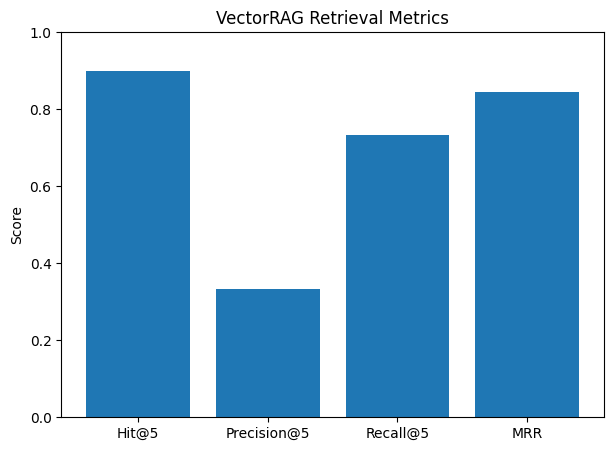

In [ ]:
retrieval_scores = {

    "Hit@5":results_df["hit@5"].mean(),

    "Precision@5":results_df["precision@5"].mean(),

    "Recall@5":results_df["recall@5"].mean(),

    "MRR":results_df["mrr"].mean()

}

plt.figure(figsize=(7,5))

plt.bar(

    retrieval_scores.keys(),

    retrieval_scores.values()

)

plt.ylim(0,1)

plt.title("VectorRAG Retrieval Metrics")

plt.ylabel("Score")

plt.show()

## 8.7 Re-plot Answer-Quality Metrics

Re-renders the ROUGE-L / BERTScore bar chart using the final (retrieval-inclusive) results DataFrame.


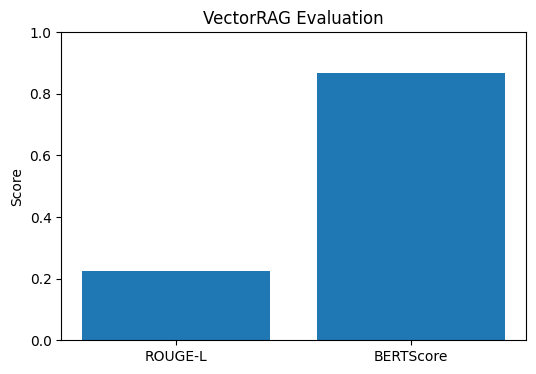

In [ ]:
import matplotlib.pyplot as plt

metrics = {

    "ROUGE-L": results_df["rougeL"].mean(),

    "BERTScore": results_df["bertscore"].mean()

}

plt.figure(figsize=(6,4))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("VectorRAG Evaluation")

plt.show()


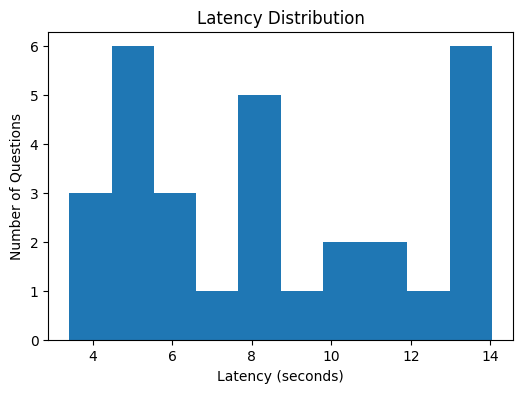

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(results_df["latency"], bins=10)

plt.xlabel("Latency (seconds)")

plt.ylabel("Number of Questions")

plt.title("Latency Distribution")

plt.show()

## 8.8 Export Final Results to CSV

Saves the complete evaluation -- answer quality and retrieval quality together -- to `vectorrag_complete_results.csv`, ready for direct comparison against `graphrag_evaluation_results.csv`.


In [ ]:
results_df.to_csv(

    "/content/vectorrag_complete_results.csv",

    index=False

)

print("Saved Successfully")

Saved Successfully


# Results: VectorRAG Evaluation Scorecard

Averaged across the same 30-question Alzheimer's evaluation set used for GraphRAG:

### Answer Quality

| Metric | Score | What it measures |
|---|---|---|
| **ROUGE-L** | **0.226** | Longest-common-subsequence lexical overlap with the expected answer |
| **BERTScore** | **0.868** | Embedding-based semantic similarity to the expected answer |

### Retrieval Quality

| Metric | Score | What it measures |
|---|---|---|
| **Hit@5** | **90.0%** | At least one of the top-5 retrieved chunks came from an expected supporting source |
| **Precision@5** | **33.3%** | Share of the top-5 retrieved chunks that came from a relevant source |
| **Recall@5** | **73.3%** | Share of the question's expected supporting sources that were retrieved |
| **MRR** | **0.844** | How high up the first correct source ranked, on average |

### Efficiency

| Metric | Value |
|---|---|
| **Average Latency** | **8.74 seconds / question** |

### Reading the scorecard

- **Retrieval is VectorRAG's strong suit.** Hit@5 of 90%, Recall@5 of 73%, and an MRR
  of 0.84 mean dense chunk retrieval is finding the right source material for almost
  every question, usually ranked at or near the top. That's a direct payoff of
  embedding full passages rather than short entity strings -- there's simply more
  semantic signal per vector.
- **Answer quality is solid and, unlike GraphRAG, tracks the expected wording
  reasonably closely.** BERTScore (~0.87) and ROUGE-L (0.226, noticeably higher than
  GraphRAG's 0.146) suggest VectorRAG's answers pick up more of the source text's own
  phrasing -- plausible, since the model is generating directly from retrieved prose
  rather than from a flattened graph context.
- **VectorRAG is also markedly faster** (8.7s vs. GraphRAG's 26.7s per question) --
  expected, since it skips the multi-hop graph traversal (entity retrieval -> subgraph
  fetch -> chunk fetch) in favor of a single embedding lookup.


